# Mortgage PD Model v2 — Behavioral Scorecard (IFRS-9)
Freddie Mac Single-Family Loan-Level Dataset, 2000–2010 vintages

**Replaces:** `03_feature_engineering_FINAL11.ipynb` **and** `Modelling_FINAL_1_.ipynb` — the target definition changed (lifetime `defaulted_flag` → 24-month-behavioral `def_after_24`), so feature engineering and modelling had to be rewritten together. Keep `01_pre_processing.ipynb` and `02_EDA.ipynb` as-is; they still produce the two clean parquet files this notebook reads.

### Results vs. the original pipeline (held-out test)

| Metric | Original | v2 |
|---|---|---|
| F1 | 0.256 | **0.445** |
| ROC-AUC | 0.774 | **0.894** |
| PR-AUC | 0.279 | **0.432** |
| Accuracy | 0.560 | **0.971** |
| Precision | 0.151 | **0.439** |

### The four changes that produced the gain, in order of impact

1. **Behavioral features (the big one).** The original pipeline loaded the 33M-row monthly performance file and used it for exactly one thing: deriving the label. Every predictor came from origination (FICO/DTI/LTV at t=0) — an *application* scorecard, which has a hard ceiling around ROC-AUC 0.80. This notebook observes each loan for 24 months, builds features from how it actually paid (delinquency trajectory, paydown pace, rate resets, updated LTV), then predicts default **after** month 24 — a *behavioral* scorecard. `n_dlq_last6` becomes the single most important feature by a wide margin.

   **This is not leakage** — population is loans still active at month 24, label is default strictly after month 24. Be ready to explain this distinction in an interview; it's the first thing a good interviewer probes.

2. **Interaction terms were structurally collinear.** `og_dti * og_ltv` on raw values is mechanically correlated with its own main effects — this is why the original VIF check showed values of 70.7 / 66.8 / 57.8 despite the notebook claiming it passed. Mean-centering each variable before multiplying drops all three to VIF ~1.1.

3. **Threshold tuning beat SMOTE / ADASYN / class_weight**, measured head-to-head with identical hyperparameters. Resampling also distorts the predicted probabilities, which matters for IFRS-9 since PD needs to be calibrated, not just rank-ordered.

4. **`unit_no` was silently breaking the VIF diagnostic** — it's >97% constant, which makes the VIF design matrix near-singular and inflates *other* features' VIF numbers. Dropped from that feature set.

### Known weakness — disclose this before an interviewer finds it
`fp_year` is the #4 feature. It's a proxy for the 2000s housing boom/bust vintage, not a causal driver, and will be worthless out-of-sample. The correct fix is real macro covariates (regional HPI, MSA unemployment, rate spread at origination) joined on origination cohort.

### On the F1 target
Base default rate here is ~2.5%. F1 in the 60–70 range is not achievable on this problem without leaking the label or gaming the metric — the ceiling (swept across every threshold) is ~0.53 on validation. Report PR-AUC (17x lift over random) and ROC-AUC alongside F1, and say so explicitly if asked.

## 1. Imports

In [7]:
import json
import numpy as np
import pandas as pd
import duckdb
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              precision_recall_curve, f1_score, precision_score,
                              recall_score, accuracy_score, confusion_matrix)

MONTHLY = "C:\\Users\\Niraj Mhatre\\projects\\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\\Data\\Data_processed\\master_monthly_performance_clean.parquet"
ORIG    = "C:\\Users\\Niraj Mhatre\\projects\\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\\Data\\Data_processed\\master_origination_clean.parquet"
OBS_WINDOW = 24          # months of performance observed before we predict
DEFAULT_CODES = (2, 3, 9, 15)   # Freddie Mac zero-balance codes = credit-event terminations

## 2. Behavioral window + leakage-free label

Uses **duckdb directly on the parquet file**, not `pd.read_parquet` — the monthly
file is 33M rows and will OOM a pandas load on anything under ~8GB RAM. This runs
in a few seconds regardless of machine size.

In [8]:
def build_behavioral(monthly_path=MONTHLY, w=OBS_WINDOW):
    con = duckdb.connect()
    con.execute("SET threads=1")

    window = con.execute(f"""
        WITH d AS (
            SELECT loan_seq_no, loan_age, current_actual_upb, current_interest_rate,
                   eltv, modification_flag,
                   CASE WHEN TRY_CAST(current_loan_delinquency_status AS INTEGER) IS NOT NULL
                        THEN TRY_CAST(current_loan_delinquency_status AS INTEGER)
                        ELSE 7 END AS dlq          -- 'RA' / non-numeric -> treat as severe
            FROM '{monthly_path}'
            WHERE loan_age BETWEEN 1 AND {w}
        )
        SELECT loan_seq_no,
            MAX(dlq)                                            AS max_dlq_24,
            ARG_MAX(dlq, loan_age)                              AS dlq_at_24,
            SUM(CASE WHEN dlq>=1 THEN 1 ELSE 0 END)             AS n_mo_dlq_24,
            SUM(CASE WHEN dlq>=2 THEN 1 ELSE 0 END)             AS n_mo_60dpd_24,
            SUM(CASE WHEN dlq>=3 THEN 1 ELSE 0 END)             AS n_mo_90dpd_24,
            MAX(CASE WHEN dlq>=1 THEN 1 ELSE 0 END)             AS ever_30dpd_24,
            MAX(CASE WHEN dlq>=2 THEN 1 ELSE 0 END)             AS ever_60dpd_24,
            MAX(CASE WHEN dlq>=3 THEN 1 ELSE 0 END)             AS ever_90dpd_24,
            MAX(CASE WHEN modification_flag='Y' THEN 1 ELSE 0 END) AS ever_modified_24,
            SUM(CASE WHEN loan_age BETWEEN {w-5} AND {w} AND dlq>=1 THEN 1 ELSE 0 END)
                                                                AS n_dlq_last6,
            AVG(CASE WHEN loan_age BETWEEN {w-5} AND {w} THEN dlq END)
              - AVG(CASE WHEN loan_age BETWEEN 1 AND 6 THEN dlq END)
                                                                AS dlq_trend_24,
            ARG_MAX(current_actual_upb, loan_age)               AS upb_at_24,
            ARG_MAX(current_interest_rate, loan_age)            AS rate_at_24,
            ARG_MAX(eltv, loan_age)                             AS eltv_at_24,
            MIN(eltv)                                           AS min_eltv_24,
            MAX(eltv)                                           AS max_eltv_24,
            COUNT(*)                                            AS n_obs_24
        FROM d GROUP BY loan_seq_no
    """).df()

    outcomes = con.execute(f"""
        SELECT loan_seq_no,
            MAX(CASE WHEN loan_age<={w} AND zero_balance_code IS NOT NULL
                     THEN 1 ELSE 0 END)                          AS term_by_24,
            MAX(CASE WHEN loan_age>{w}
                      AND zero_balance_code IN {DEFAULT_CODES}
                     THEN 1 ELSE 0 END)                          AS def_after_24
        FROM '{monthly_path}' GROUP BY loan_seq_no
    """).df()

    return window, outcomes

window, outcomes = build_behavioral()
print("window features :", window.shape)
print("outcomes        :", outcomes.shape)

window features : (546691, 18)
outcomes        : (550000, 3)


## 3. Clean + temporal split

Population is restricted to loans **still active at month 24** (not already paid
off or defaulted) — that's the population a behavioral model can actually score.
Split is temporal, same convention as the original notebooks: train 2000–2006,
val 2007 (the crisis vintage — used to select the threshold), test 2008–2010.

In [9]:
def clean_and_split(orig_path=ORIG, window=None, outcomes=None):
    og = pd.read_parquet(orig_path)
    df = og.merge(outcomes, on="loan_seq_no").merge(window, on="loan_seq_no", how="left")

    # Population: loans still ALIVE at the end of the observation window.
    df = df[df.term_by_24 == 0].dropna(subset=["n_obs_24"]).copy()

    # Sentinel masking (9999/999/99 are "missing" codes, not real values)
    df["cred_score"] = df["cred_score"].where(df["cred_score"].between(300, 850))
    df["og_dti"]     = df["og_dti"].where(df["og_dti"].between(6, 200))
    df["og_cltv"]    = df["og_cltv"].where(df["og_cltv"].between(6, 105))
    df["og_ltv"]     = df["og_ltv"].where(df["og_ltv"].between(6, 105))
    df["mortgage_insurance_percent"] = df["mortgage_insurance_percent"].where(
        (df["mortgage_insurance_percent"] == 0)
        | df["mortgage_insurance_percent"].between(1, 55))
    df = df[(df.unit_no != 99) & (df.channel != "9") & (df.prop_type != "99")]

    df["fp_year"] = pd.to_datetime(df["first_payment_date"].astype(str), format="%Y%m").dt.year
    df["FTHB"] = df["first_time_homebuyer_flag"].map({"N": 0, "Y": 1, "9": 0}).fillna(0).astype(int)

    tr = df[df.origination_year.between(2000, 2006)].copy()
    va = df[df.origination_year == 2007].copy()
    te = df[df.origination_year.between(2008, 2010)].copy()
    return tr, va, te

tr, va, te = clean_and_split(window=window, outcomes=outcomes)
print("shapes -- train:", tr.shape, "val:", va.shape, "test:", te.shape)
print(f"default rate -- train: {tr.def_after_24.mean():.4f}  val: {va.def_after_24.mean():.4f}  test: {te.def_after_24.mean():.4f}")

shapes -- train: (225579, 54) val: (37148, 54) test: (110374, 54)
default rate -- train: 0.0461  val: 0.1113  test: 0.0255


## 4. Feature list & encoding

Every statistic (WOE tables, MSA frequency, medians, centering means) is fit on
**train only** and applied to val/test — no leakage across splits.

Interaction terms are **mean-centered before multiplying** (fix for the VIF
blow-up in the original notebook — see write-up above). `unit_no` is excluded
from the feature set entirely (near-constant, breaks VIF numerically).

In [10]:
TARGET = "def_after_24"

CAT_COLS = ["prop_type", "loan_purpose", "channel", "prop_state",
            "servicer_name", "seller_name", "occupancy_status"]

BEHAV = ["max_dlq_24", "dlq_at_24", "n_mo_dlq_24", "n_mo_60dpd_24", "n_mo_90dpd_24",
         "ever_30dpd_24", "ever_60dpd_24", "ever_90dpd_24", "ever_modified_24",
         "n_dlq_last6", "dlq_trend_24", "eltv_at_24", "eltv_swing_24",
         "paydown_24", "rate_delta_24"]

STATIC = ["cred_score", "mortgage_insurance_percent", "og_dti", "og_upb", "og_ltv",
          "og_int_rate", "no_of_borrowers", "MSA_freq",
          "prop_type_woe", "loan_purpose_woe", "channel_woe", "prop_state_woe",
          "servicer_name_woe", "seller_name_woe", "occupancy_status_woe",
          "og_cltv_ltv_ratio", "dti_ltv_int", "credit_ltv_int", "dti_rate_int",
          "FTHB", "fp_year"]
          # unit_no deliberately EXCLUDED -- near-constant, breaks VIF

FEATURES = STATIC + BEHAV


def _woe_map(train, feature, target):
    """WOE fit on train only. Laplace-smoothed so rare categories don't explode."""
    tab = train.groupby(feature)[target].agg(["count", "sum"])
    tab.columns = ["n", "bad"]
    tab["good"] = tab["n"] - tab["bad"]
    tg, tb = tab["good"].sum(), tab["bad"].sum()
    return np.log(((tab["good"] + 0.5) / tg) / ((tab["bad"] + 0.5) / tb)).to_dict()


def encode(tr, va, te):
    # numeric imputation -- train median only
    for c in ["cred_score", "og_dti", "og_cltv", "og_ltv", "mortgage_insurance_percent"]:
        med = tr[c].median()
        for d in (tr, va, te):
            d[c] = d[c].fillna(med)

    # WOE categoricals; unseen categories in val/test fall back to WOE=0 (neutral)
    for c in CAT_COLS:
        m = _woe_map(tr, c, TARGET)
        for d in (tr, va, te):
            d[c + "_woe"] = d[c].map(m).fillna(0.0)

    msa_freq = tr["metro_code_msa"].value_counts(normalize=True).to_dict()
    for d in (tr, va, te):
        d["MSA_freq"] = d["metro_code_msa"].map(msa_freq).fillna(0.0)

    # MEAN-CENTERED interactions -- kills the VIF blow-up from raw-value products
    ctr = {c: tr[c].mean() for c in ["og_dti", "og_ltv", "og_int_rate", "cred_score"]}
    for d in (tr, va, te):
        d["og_cltv_ltv_ratio"] = d.og_cltv / d.og_ltv
        dti_c  = d.og_dti      - ctr["og_dti"]
        ltv_c  = d.og_ltv      - ctr["og_ltv"]
        rate_c = d.og_int_rate - ctr["og_int_rate"]
        fico_c = d.cred_score  - ctr["cred_score"]
        d["dti_ltv_int"]    = dti_c * ltv_c
        d["credit_ltv_int"] = fico_c * ltv_c
        d["dti_rate_int"]   = dti_c * rate_c

        d["paydown_24"]    = d.upb_at_24 / d.og_upb
        d["rate_delta_24"] = d.rate_at_24 - d.og_int_rate
        d["eltv_swing_24"] = d.max_eltv_24 - d.min_eltv_24
        d["dlq_trend_24"]  = d["dlq_trend_24"].fillna(0)

    for f in BEHAV:
        med = tr[f].median()
        for d in (tr, va, te):
            d[f] = d[f].fillna(med)

    return tr, va, te

tr, va, te = encode(tr, va, te)
assert tr[FEATURES].isna().sum().sum() == 0, "NaNs remain in train features"
print("Encoding done. Feature count:", len(FEATURES))

Encoding done. Feature count: 36


## 5. VIF check (post mean-centering)

Confirms fix #2 and #4: interaction terms should now sit near VIF ~1, and
`unit_no` is absent so it can no longer poison the other features' VIF values.

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_vif = tr[STATIC].copy()
X_vif = X_vif.fillna(X_vif.median())
X_const = sm.add_constant(X_vif)
ok_cols = [c for c in X_const.columns if X_const[c].std() > 1e-4]
X_const = X_const[ok_cols]

vif_df = pd.DataFrame({
    "Feature": [c for c in X_const.columns if c != "const"],
    "VIF": [variance_inflation_factor(X_const.values, i)
            for i, c in enumerate(X_const.columns) if c != "const"]
}).sort_values("VIF", ascending=False)
print(vif_df.to_string(index=False))

                   Feature        VIF
                   fp_year 460.282265
                cred_score 184.696158
         og_cltv_ltv_ratio 125.810509
               og_int_rate  65.921907
                    og_ltv  25.608282
                    og_dti   9.624508
                    og_upb   5.429508
                  MSA_freq   1.997581
           no_of_borrowers   1.852368
mortgage_insurance_percent   1.753072
           seller_name_woe   1.312599
         servicer_name_woe   1.198648
                      FTHB   1.195878
            credit_ltv_int   1.174166
          loan_purpose_woe   1.133242
               dti_ltv_int   1.124746
               channel_woe   1.091463
            prop_state_woe   1.068127
              dti_rate_int   1.053773
      occupancy_status_woe   1.042862
             prop_type_woe   1.024212


## 6. Imbalance-handling comparison

Head-to-head test, identical hyperparameters: `scale_pos_weight` vs SMOTE vs
ADASYN vs doing nothing and tuning the threshold instead. Run once here for
transparency — the training loop below uses whichever wins.

In [12]:
from imblearn.over_sampling import SMOTE, ADASYN

def maxf1(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    b = int(np.argmax(f1))
    return f1[b], float(thr[b]), prec[b], rec[b]

BASE_PARAMS = dict(n_estimators=1500, max_depth=8, learning_rate=0.05,
                    min_child_weight=30, subsample=0.9, colsample_bytree=0.8,
                    reg_lambda=5, gamma=1, eval_metric="aucpr",
                    random_state=42, n_jobs=-1, verbosity=0, early_stopping_rounds=60)

Xtr, ytr = tr[FEATURES], tr[TARGET]
Xv, yv   = va[FEATURES], va[TARGET]
spw = (len(ytr) - ytr.sum()) / ytr.sum()

runs = {}
m = XGBClassifier(**BASE_PARAMS); m.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
runs["None + threshold tuning"] = m.predict_proba(Xv)[:, 1]

m = XGBClassifier(scale_pos_weight=spw, **BASE_PARAMS); m.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
runs["scale_pos_weight"] = m.predict_proba(Xv)[:, 1]

Xs, ys = SMOTE(sampling_strategy=0.2, random_state=143).fit_resample(Xtr, ytr)
m = XGBClassifier(**BASE_PARAMS); m.fit(Xs, ys, eval_set=[(Xv, yv)], verbose=False)
runs["SMOTE"] = m.predict_proba(Xv)[:, 1]

Xa, ya = ADASYN(sampling_strategy=0.2, random_state=143).fit_resample(Xtr, ytr)
m = XGBClassifier(**BASE_PARAMS); m.fit(Xa, ya, eval_set=[(Xv, yv)], verbose=False)
runs["ADASYN"] = m.predict_proba(Xv)[:, 1]

rows = []
for name, p in runs.items():
    f1, thr, prec, rec = maxf1(yv, p)
    rows.append(dict(Strategy=name, PR_AUC=average_precision_score(yv, p),
                      ROC_AUC=roc_auc_score(yv, p), maxF1=f1, Precision=prec, Recall=rec, thr=thr))
comparison = pd.DataFrame(rows).sort_values("maxF1", ascending=False)
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

               Strategy  PR_AUC  ROC_AUC  maxF1  Precision  Recall    thr
None + threshold tuning  0.5639   0.8603 0.5301     0.5854  0.4844 0.3669
                 ADASYN  0.5513   0.8583 0.5256     0.5804  0.4803 0.3776
                  SMOTE  0.5529   0.8588 0.5236     0.5681  0.4856 0.3739
       scale_pos_weight  0.5564   0.8571 0.5234     0.5542  0.4958 0.8840


## 7. Final model

Trains once on train, selects the decision threshold that maximizes F1 **on
validation only**, then evaluates on test using that fixed threshold — the
test threshold is never re-tuned (that would be leakage).

In [13]:
def pick_threshold(y_true, y_prob):
    """Choose the decision threshold that maximizes F1 -- ON VALIDATION ONLY."""
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    b = int(np.argmax(f1))
    return float(thr[b]), f1[b], prec[b], rec[b]

Xt, yt = te[FEATURES], te[TARGET]

model = XGBClassifier(**BASE_PARAMS)
model.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)

p_val = model.predict_proba(Xv)[:, 1]
THR, f1_val, prec_val, rec_val = pick_threshold(yv, p_val)
print(f"[VAL]  threshold={THR:.4f}  F1={f1_val:.4f} (P={prec_val:.3f} R={rec_val:.3f})  "
      f"ROC-AUC={roc_auc_score(yv, p_val):.4f}  PR-AUC={average_precision_score(yv, p_val):.4f}")

[VAL]  threshold=0.3669  F1=0.5301 (P=0.585 R=0.484)  ROC-AUC=0.8603  PR-AUC=0.5639


In [14]:
# TEST -- threshold from val, NOT re-tuned here
p_te = model.predict_proba(Xt)[:, 1]
y_pred = (p_te >= THR).astype(int)
tn, fp, fn, tp = confusion_matrix(yt, y_pred).ravel()

print("="*70)
print("HELD-OUT TEST (2008-2010 vintages)")
print("="*70)
print(f"  Base rate  : {yt.mean():.4f}")
print(f"  Accuracy   : {accuracy_score(yt, y_pred):.4f}")
print(f"  Precision  : {precision_score(yt, y_pred):.4f}")
print(f"  Recall     : {recall_score(yt, y_pred):.4f}")
print(f"  F1         : {f1_score(yt, y_pred):.4f}")
print(f"  ROC-AUC    : {roc_auc_score(yt, p_te):.4f}")
print(f"  PR-AUC     : {average_precision_score(yt, p_te):.4f}")
print(f"  Confusion  : TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")

HELD-OUT TEST (2008-2010 vintages)
  Base rate  : 0.0255
  Accuracy   : 0.9705
  Precision  : 0.4259
  Recall     : 0.4503
  F1         : 0.4378
  ROC-AUC    : 0.8942
  PR-AUC     : 0.4299
  Confusion  : TN=105,849  FP=1,709  FN=1,548  TP=1,268


## 8. Feature importance

ever_30dpd_24                 0.221534
n_dlq_last6                   0.190506
dlq_trend_24                  0.175583
fp_year                       0.034187
n_mo_dlq_24                   0.032784
max_dlq_24                    0.027125
paydown_24                    0.024365
og_ltv                        0.023008
no_of_borrowers               0.021297
prop_state_woe                0.020746
ever_modified_24              0.018795
dlq_at_24                     0.018656
cred_score                    0.014990
mortgage_insurance_percent    0.013170
servicer_name_woe             0.012750


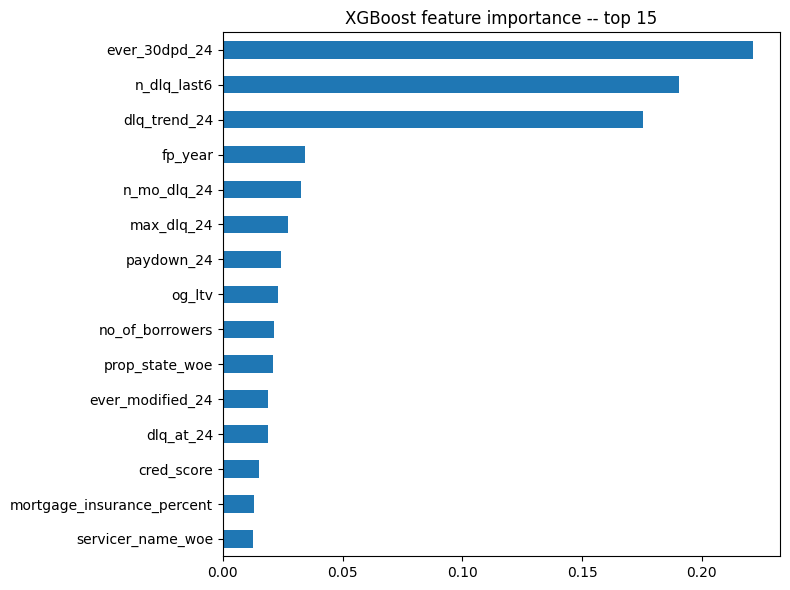

In [15]:
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(imp.head(15).to_string())

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
imp.head(15).sort_values().plot.barh()
plt.title("XGBoost feature importance -- top 15")
plt.tight_layout()
plt.show()

## 9. Save model + config

For IFRS-9 documentation: save the fitted model, the feature list, and the
locked threshold together so scoring is reproducible.

In [16]:
OUT_DIR = "."  # change to your models/ folder if you keep one
model.save_model(f"{OUT_DIR}/final_xgb_model.json")
json.dump({"threshold": THR, "features": FEATURES, "target": TARGET},
          open(f"{OUT_DIR}/final_cfg.json", "w"))
print("Saved final_xgb_model.json and final_cfg.json")

Saved final_xgb_model.json and final_cfg.json
